# 조건부 라우팅, 분기 흐름 만들기
- 지금까지는 노드가 순서대로 흘렀습니다. 실제 에이전트는 **상황에 따라 다음 노드를 골라야** 합니다 ("도구가 필요하면 → 도구 노드, 답이 충분하면 → 끝"). 
- `add_conditional_edges` 로 분기.

## 환경 준비


```
OPENAI_API_KEY=sk-...
```

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

print("OPENAI_API_KEY:", "있음" if os.getenv("OPENAI_API_KEY") else "없음")

OPENAI_API_KEY: 있음


## 1. 가장 단순한 분기, 길이로 결정

- 사용자 메시지 길이로 "짧으면 짧게 답, 길면 길게 답" 분기.

In [2]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage

In [3]:
llm = init_chat_model('openai:gpt-5.4-mini')

In [ ]:
def short_answer(state: MessagesState) -> dict:
    """한 문장으로 짧게 답."""
    msgs = state["messages"] + [HumanMessage("한 문장으로만 답해줘.")]
    ai = llm.invoke(msgs)
    return {"messages": [ai]}


def long_answer(state: MessagesState) -> dict:
    """3 문장 이상 자세히 답."""
    msgs = state["messages"] + [HumanMessage("3~5 문장으로 자세히 답해줘.")]
    ai = llm.invoke(msgs)
    return {"messages": [ai]}


def router(state: MessagesState) -> str:
    """마지막 사용자 메시지가 길면 long, 짧으면 short."""
    last = state["messages"][-1].content
    return "long" if len(last) > 50 else "short"


In [33]:
graph = StateGraph(MessagesState)
graph.add_node("short", short_answer)
graph.add_node("long", long_answer)

In [34]:
graph.add_conditional_edges(
    START,                                  # 어디서 분기?
    router,                                 # 어떤 함수로 분기를 결정?
    {"short": "short", "long": "long"}      # 반환값 -> 다음 노드
)
graph.add_edge("short", END)
graph.add_edge("long", END)

In [35]:
app = graph.compile()

In [36]:
result1 = app.invoke({'messages': [HumanMessage('고객지원 담당자 배송 확인')]})
print(result1['messages'][-1].content)
print()

result2 = app.invoke({'messages': [HumanMessage('이커머스 고객지원 담당자가 배송 지연 문의를 처리할 때 확인해야 할 것이 무엇이 있을까요?')]})
print(result2['messages'][-1].content)
print()

고객님의 배송 상태를 확인해드리겠습니다.

주문 상태, 배송사 추적 정보, 출고 여부, 예상 배송일, 지연 사유, 고객 안내 가능 보상 여부를 확인해야 합니다.



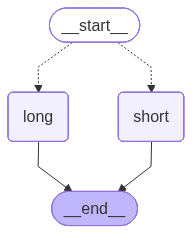

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## 2. 도구 호출 분기, LLM 이 도구 부르면 도구 노드로

- 진짜 에이전트의 핵심 패턴. LLM 응답에 `tool_calls` 가 있으면 도구 실행, 없으면 끝.

In [10]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

In [ ]:
@tool
def estimate_delivery_days(region: str, delayed: bool = False) -> str:
    """배송 지역과 지연 여부로 예상 배송일을 계산한다."""
    base_days = {"서울": 1, "수도권": 2, "지방": 3, "제주": 5}.get(region, 3)
    if delayed:
        base_days += 2
    return f"예상 배송일: {base_days}일"


@tool
def calculate_delay_compensation(delay_days: int, order_amount: int) -> str:
    """배송 지연 일수와 주문 금액으로 보상 쿠폰 금액을 계산한다."""
    if delay_days < 3:
        return "보상 대상 아님"
    coupon = min(int(order_amount * 0.1), 10000)
    return f"배송 지연 {delay_days}일: {coupon}원 쿠폰 권장"

@tool
def lookup_order_status(order_id: int, order_status: int, reward_amount: int) -> int:
    """주문 상태 확인 후 보상 금액을 계산한다."""
    if order_status > 0:
        return "주문 상태까지 확인되었으니 보상 금액을 계산한다."
    

In [ ]:
# LLM이 사용할 수 있는 도구 목록
llm_tools = llm.bind_tools([estimate_delivery_days, calculate_delay_compensation, lookup_order_status])

# 도구 이름으로 실제 도구 함수를 찾기 위한 딕셔너리.
tools_by_name = {t.name: t for t in [estimate_delivery_days, calculate_delay_compensation, lookup_order_status]}

In [13]:
def call_llm(state: MessagesState) -> dict:
    """LLM 한 번 호출. 도구를 부를 수도, 답을 줄 수도."""
    ai = llm_tools.invoke(state["messages"])
    return {"messages": [ai]}


def call_tools(state: MessagesState) -> dict:
    """LLM 이 부른 도구들을 실행하고 ToolMessage 로 결과 반환."""
    last = state["messages"][-1]
    tool_msgs = []
    for call in last.tool_calls:
        tool = tools_by_name[call["name"]]
        result = tool.invoke(call["args"])
        tool_msgs.append(ToolMessage(str(result), tool_call_id=call["id"]))
    return {"messages": tool_msgs}


def needs_tools(state: MessagesState) -> str:
    """마지막 ai 메시지에 tool_calls 가 있으면 'tools', 없으면 'end'."""
    return "tools" if state["messages"][-1].tool_calls else "end"

In [14]:
graph2 = StateGraph(MessagesState)
graph2.add_node('llm', call_llm)
graph2.add_node('tools', call_tools)

graph2.add_edge(START, 'llm')
graph2.add_conditional_edges(
    'llm',                           # llm 노드 끝나면
    needs_tools,                     # 라우터로 결정
    {'tools': 'tools', 'end': END}
)

graph2.add_edge('tools', 'llm')      # 도구 실행 후 다시 llm으로 (루프!)

app2 = graph2.compile()

In [15]:
result = app2.invoke({
    'messages':[HumanMessage('제주 지역 고객 주문이 5일 지연됐어. 주문금액 80,000원인데 예상 배송일과 보상 쿠폰을 계산해줘.')]
})

In [16]:
print(result['messages'][-1].content)
for m in result['messages']:
    print(f'[{type(m).__name__}] {str(m.content)}')

제주 지역 고객 주문 기준으로 계산해보면:

- 예상 배송일: 7일
- 보상 쿠폰: 8,000원

필요하시면 이 결과를 고객 안내문 형태로도 정리해드릴게요.
[HumanMessage] 제주 지역 고객 주문이 5일 지연됐어. 주문금액 80,000원인데 예상 배송일과 보상 쿠폰을 계산해줘.
[AIMessage] 
[ToolMessage] 예상 배송일: 7일
[ToolMessage] 배송 지연 5일: 8000원 쿠폰 권장
[AIMessage] 제주 지역 고객 주문 기준으로 계산해보면:

- 예상 배송일: 7일
- 보상 쿠폰: 8,000원

필요하시면 이 결과를 고객 안내문 형태로도 정리해드릴게요.


### 2.1.도구 루프가 헷갈리는 이유

1. **`tool_call_id` 가 왜 필요한가**
   - LLM 이 한 번에 도구 여러 개를 부를 수 있어요. 결과를 돌려줄 때 "어느 호출의 결과인지" 식별하려고 ID 를 같이 넘깁니다.
2. **`tools → llm` 으로 다시 돌아가는 이유**
   - 도구 결과를 받았다고 끝이 아닙니다. LLM 이 그 결과를 보고 "최종 답" 을 한 번 더 만들어줘야 함. 그래서 루프.
3. **언제 멈추나**
   - LLM 이 더 이상 도구를 안 부르고 그냥 답만 주면 (`tool_calls` 가 비어있으면) `END` 로 가서 종료.

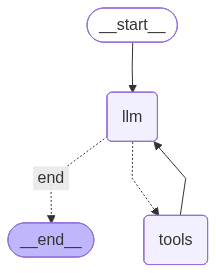

In [17]:
display(Image(app2.get_graph().draw_mermaid_png()))

### 2.2. `ToolNode` + `tools_condition`, prebuilt 로 단순화
- 위에서 수동으로 짠 "도구 실행 노드" 와 "도구 호출 여부 라우터" 를 LangGraph 가 미리 만들어 둔 게 있습니다. 코드가 훨씬 짧아져요.

In [23]:
from langgraph.prebuilt import ToolNode, tools_condition

tool_node = ToolNode([estimate_delivery_days, calculate_delay_compensation])

graph_pb = StateGraph(MessagesState)
graph_pb.add_node('llm', call_llm)
graph_pb.add_node('tools', tool_node)

graph_pb.add_edge(START, 'llm')
graph_pb.add_conditional_edges('llm', tools_condition)
graph_pb.add_edge('tools', 'llm')

app_pd = graph_pb.compile()

In [24]:
result = app_pd.invoke(
    {"messages":[HumanMessage("제주 배송 지연 5일, 주문금액 80000원인 티켓의 예상 배송일과 보상 쿠폰을 알려줘.")]},
    config={'recursion_limit':10}   # 그래프 노드 호출 최대 10번. 모델이 계속 도구를 호출하는 무한 루프에 빠지는 상황을 막기 위한 안전 장치.
)
print(result["messages"][-1].content)

제주 배송의 예상 배송일은 **7일**입니다.  
배송 지연 5일, 주문금액 80,000원 기준 보상 쿠폰은 **8,000원** 권장입니다.


## 3. 라우터를 LLM 자체에 맡기기

- 라우터를 if-else 가 아니라 LLM 에게 물어볼 수도. 분류 모델처럼.

In [25]:
from pydantic import BaseModel, Field
from typing import Literal

In [37]:
class RouteDecision(BaseModel):
    """사용자 의도 분류."""
    intent: Literal["support_ticket", "code_help", "casual_chat", "refund_policy"] = Field(
        description="사용자가 원하는 것의 유형"
    )

In [39]:

router_llm = llm.with_structured_output(RouteDecision)


def llm_router(state: MessagesState) -> str:
    """LLM 으로 의도 분류 후 다음 노드 결정."""
    decision = router_llm.invoke([
        HumanMessage("아래 메시지의 의도를 분류해줘:\n" + state["messages"][-1].content)
    ])
    return decision.intent


def answer_support(state: MessagesState) -> dict:
    msgs = state["messages"] + [HumanMessage("너는 이커머스 고객지원 매니저. 티켓 처리 관점으로 답해줘.")]
    return {"messages": [llm.invoke(msgs)]}


def answer_code(state: MessagesState) -> dict:
    msgs = state["messages"] + [HumanMessage("너는 시니어 개발자. 코드 위주로 답해.")]
    return {"messages": [llm.invoke(msgs)]}


def answer_casual(state: MessagesState) -> dict:
    msgs = state["messages"] + [HumanMessage("친구처럼 짧고 가볍게 답해.")]
    return {"messages": [llm.invoke(msgs)]}


def answer_refund(state: MessagesState) -> dict:
    msgs = state["messages"] + [HumanMessage("정해져있는 정책에 대해서 정직하게 이야기해.")]
    return {"messages": [llm.invoke(msgs)]}

In [40]:
graph3 = StateGraph(MessagesState)
graph3.add_node('support', answer_support)
graph3.add_node('code', answer_code)
graph3.add_node('casual', answer_casual)
graph3.add_node('refund', answer_refund)
graph3.add_conditional_edges(
    START,
    llm_router,
    {'support_ticket':'support',
     'code_help':'code',
     'casual_chat':'casual',
     'refund_policy':'refund'}
)
graph3.add_edge('support',END)
graph3.add_edge('code',END)
graph3.add_edge('casual',END)
graph3.add_edge('refund',END)

app3 = graph3.compile()

In [43]:
questions = [
    '고객 배송이 5일째 안 온다고 화났어. 어떻게 응대할까?',
    'for문에서 enumerate가 뭐야?',
    '오늘 점심 뭐먹?',
    '뭐 어떻게 환불해줄 건데? 배송이 5일째 안 와서 취소한 거잖아.'
]

In [44]:
for q in questions:
    print(f"Q: {q}")
    r = app3.invoke({"messages": [HumanMessage(q)]})
    print(f"A: {r['messages'][-1].content[:80]}")
    print()

Q: 고객 배송이 5일째 안 온다고 화났어. 어떻게 응대할까?
A: 티켓 처리 관점에서는 **“감정 진정 → 사실 확인 → 즉시 조치 제안 → 후속 약속”** 순서로 응대하는 게 좋습니다.  
핵심은 **변명보다

Q: for문에서 enumerate가 뭐야?
A: `enumerate()`는 **for문에서 “인덱스 + 값”을 같이 받을 때** 쓰는 함수입니다.

## 기본 형태
```python
for i

Q: 오늘 점심 뭐먹?
A: 국밥이나 제육 어때? 든든하고 실패 확률 낮아 😌

Q: 뭐 어떻게 환불해줄 건데? 배송이 5일째 안 와서 취소한 거잖아.
A: 배송 지연으로 취소하신 거라면, **환불은 결제하신 수단으로 원복**되는 방식이 일반적입니다. 다만 실제 처리는 판매처/플랫폼 정책과 취소 시점



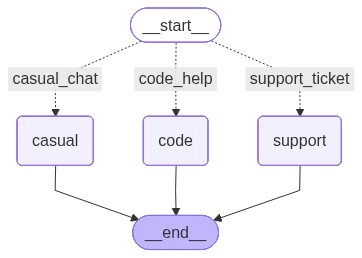

In [30]:
display(Image(app3.get_graph().draw_mermaid_png()))

## 4. 정리

| 패턴 | 라우터 함수 반환 | 용도 |
|---|---|---|
| 길이·키워드 분기 | 단순 if-else | 빠른 분류 |
| 도구 호출 분기 | `tool_calls` 존재 여부 | 에이전트 표준 (다음 노트북에서 ReAct 로 확장) |
| LLM 의도 분류 | Pydantic Literal 의 enum 값 | 도메인 분기 (고객지원/코딩/잡담 등) |


## [실습]

1. 1번 그래프의 임계값 30 을 50 으로 바꿔보고 결과 차이 비교.
2. 3번 의도 분류에 `"refund_policy"` 도 추가해 4-way 분기.
3. 2번 도구 그래프에 `lookup_order_status(order_id)` 도구 추가. "주문 상태 확인 후 보상 계산" 시나리오.
4. 3번 그래프에서 의도 분류가 한 번에 안 잡힐 때 "다시 묻기" 노드 추가.
5. State 에 `attempt_count` 필드를 두고, 도구 호출 루프가 3회 넘으면 강제 종료하는 안전장치.
